# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset yang aku gunakan adalah Mango Ripening Stage Classification yang berisi gambar buaah mangga berdasarkan tingkat kematangannya. Dataset ini akan digunakan untuk membangun model machine learning atau deep learning yang dapat mengklasifikasikan tingkat kematangan mangga secara otomatis menggunakan gambar ddigital.

Sumber datasetnya : https://www.kaggle.com/datasets/srabon00/mango-ripening-stage-classification

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [37]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
dataset_path = "/content/drive/MyDrive/Eksperimen_SML_Aulia Silmi Mardiyanti/mango_dataset"

In [40]:
classes = os.listdir(dataset_path)

print("Jumlah kelas:", len(classes))
print("Nama kelas:")
for cls in classes:
    print("-", cls)

Jumlah kelas: 3
Nama kelas:
- UnRipe
- Ripe
- OverRipe


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [41]:
total_images = 0

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):
        total_images += len(os.listdir(class_path))

print("Total gambar:", total_images)

Total gambar: 975


In [42]:
class_counts = {}

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):
        class_counts[cls] = len(os.listdir(class_path))

df_class = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Count"]
)

df_class

,Class,Count
0,UnRipe,911
1,Ripe,43
2,OverRipe,21


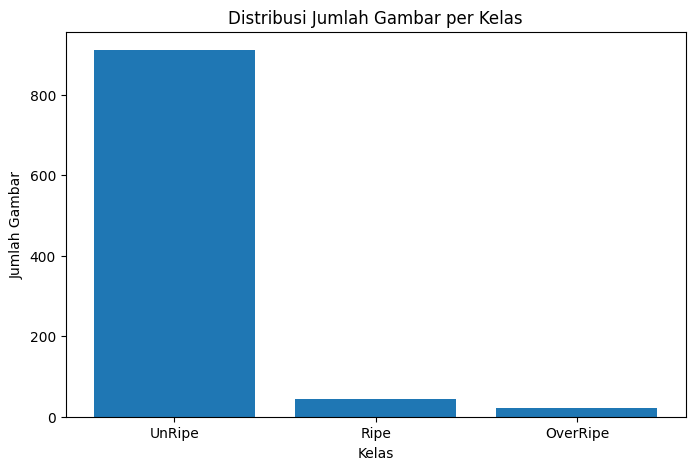

In [43]:
plt.figure(figsize=(8,5))

plt.bar(
    df_class["Class"],
    df_class["Count"]
)

plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")

plt.show()

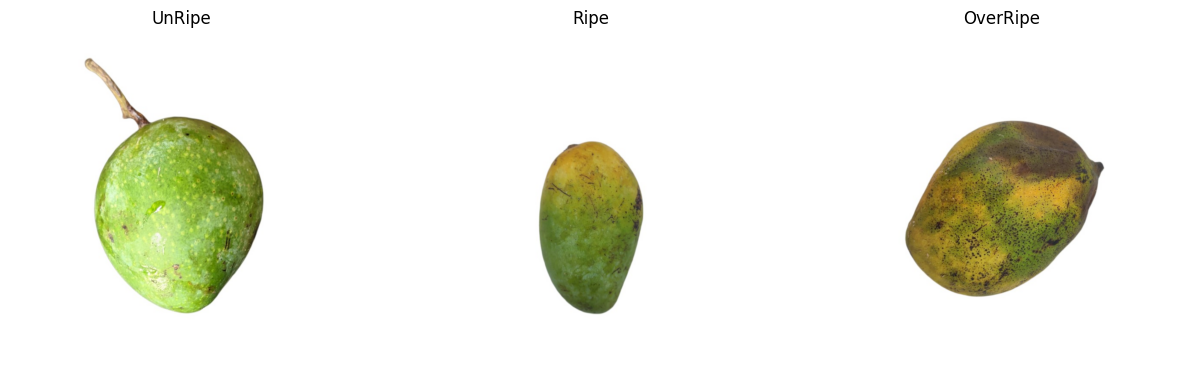

In [44]:
plt.figure(figsize=(15,5))

for i, cls in enumerate(classes):

    img_name = os.listdir(
        os.path.join(dataset_path, cls)
    )[0]

    img_path = os.path.join(
        dataset_path,
        cls,
        img_name
    )

    img = Image.open(img_path)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [45]:
widths = []
heights = []

for cls in classes:

    class_path = os.path.join(
        dataset_path,
        cls
    )

    for img_name in os.listdir(class_path):

        img_path = os.path.join(
            class_path,
            img_name
        )

        try:
            img = Image.open(img_path)

            widths.append(img.size[0])
            heights.append(img.size[1])

        except:
            pass

In [46]:
print("Rata-rata Width :", np.mean(widths))
print("Rata-rata Height :", np.mean(heights))

print("Width Minimum :", np.min(widths))
print("Width Maximum :", np.max(widths))

print("Height Minimum :", np.min(heights))
print("Height Maximum :", np.max(heights))

Rata-rata Width : 799.977435897436
Rata-rata Height : 799.9179487179487
Width Minimum : 778
Width Maximum : 800
Height Minimum : 755
Height Maximum : 800


Berdasarkan dari eksplorasi data, hasilnya adalah sebagai berrikut:
1. Dataset terdiri dari 3 kelas
2. Dataset berisi sejumlah gambar yang digunakan untuk klasifikasi tingkat kematangan buah mangga.
3. Distribisu jumlah gambar pada dataset rekatif sseimbang antar kelas.
4. Sampel gambar menunjukkan adanya perbedaan warna dan tekstur yang dapaat dimanfaatkan model untuk membedakan tinkat kematangan  buah
5. Resolusi gambar tidak seragam sehingga diperlukan untuk resize sebelum dilatih model

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [47]:
corrupt_images = []

for cls in classes:

    class_path = os.path.join(
        dataset_path,
        cls
    )

    for img_name in os.listdir(class_path):

        img_path = os.path.join(
            class_path,
            img_name
        )

        try:
            Image.open(img_path)

        except:
            corrupt_images.append(img_path)

print("Jumlah gambar rusak:", len(corrupt_images))

Jumlah gambar rusak: 0


In [48]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [49]:
datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True,

    validation_split=0.2
)

In [50]:
train_generator = datagen.flow_from_directory(

    dataset_path,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'
)

Found 781 images belonging to 3 classes.


In [51]:
val_generator = datagen.flow_from_directory(

    dataset_path,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation'
)

Found 194 images belonging to 3 classes.


In [52]:
images, labels = next(train_generator)

print("Shape gambar :", images.shape)
print("Shape label :", labels.shape)

Shape gambar : (32, 224, 224, 3)
Shape label : (32, 3)


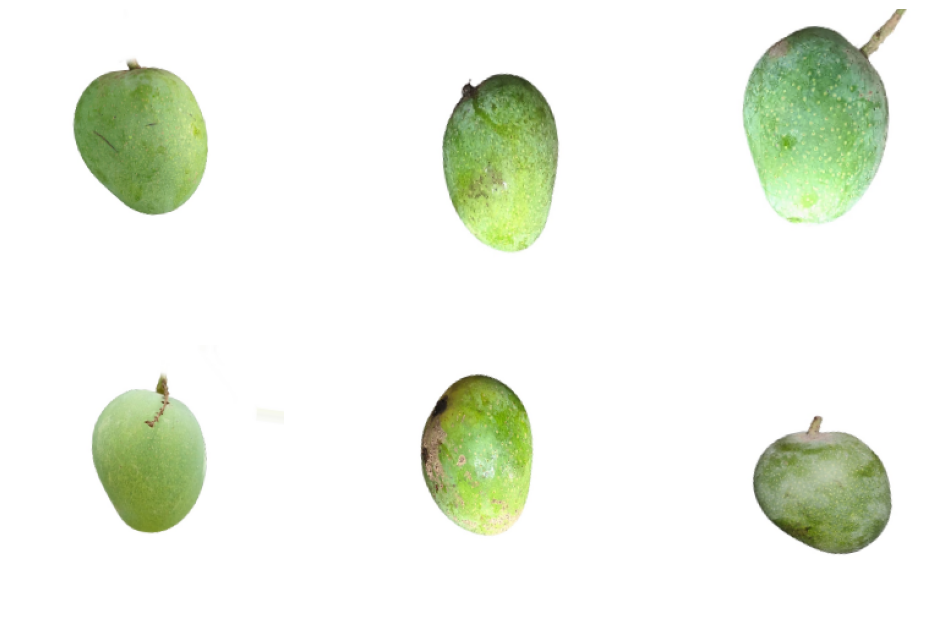

In [53]:
plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

Tahapan preposesing yang sudah dilakukan adalah sebagai berikut:
1. Memeriksa gambarr yang rusak
2. Resize seluruh gambar yang digunakan menjadi 224 x 224 pixwl
3. Normalisasi nilai pixel ke rentang 0-1 menggunakan rescale
4. Data augmentation untuk meningkatkan variasi data pelatihan
5. Pembagian data (training 80% dan validation 20%)